Goal reached at 452.80s. Ending simulation.


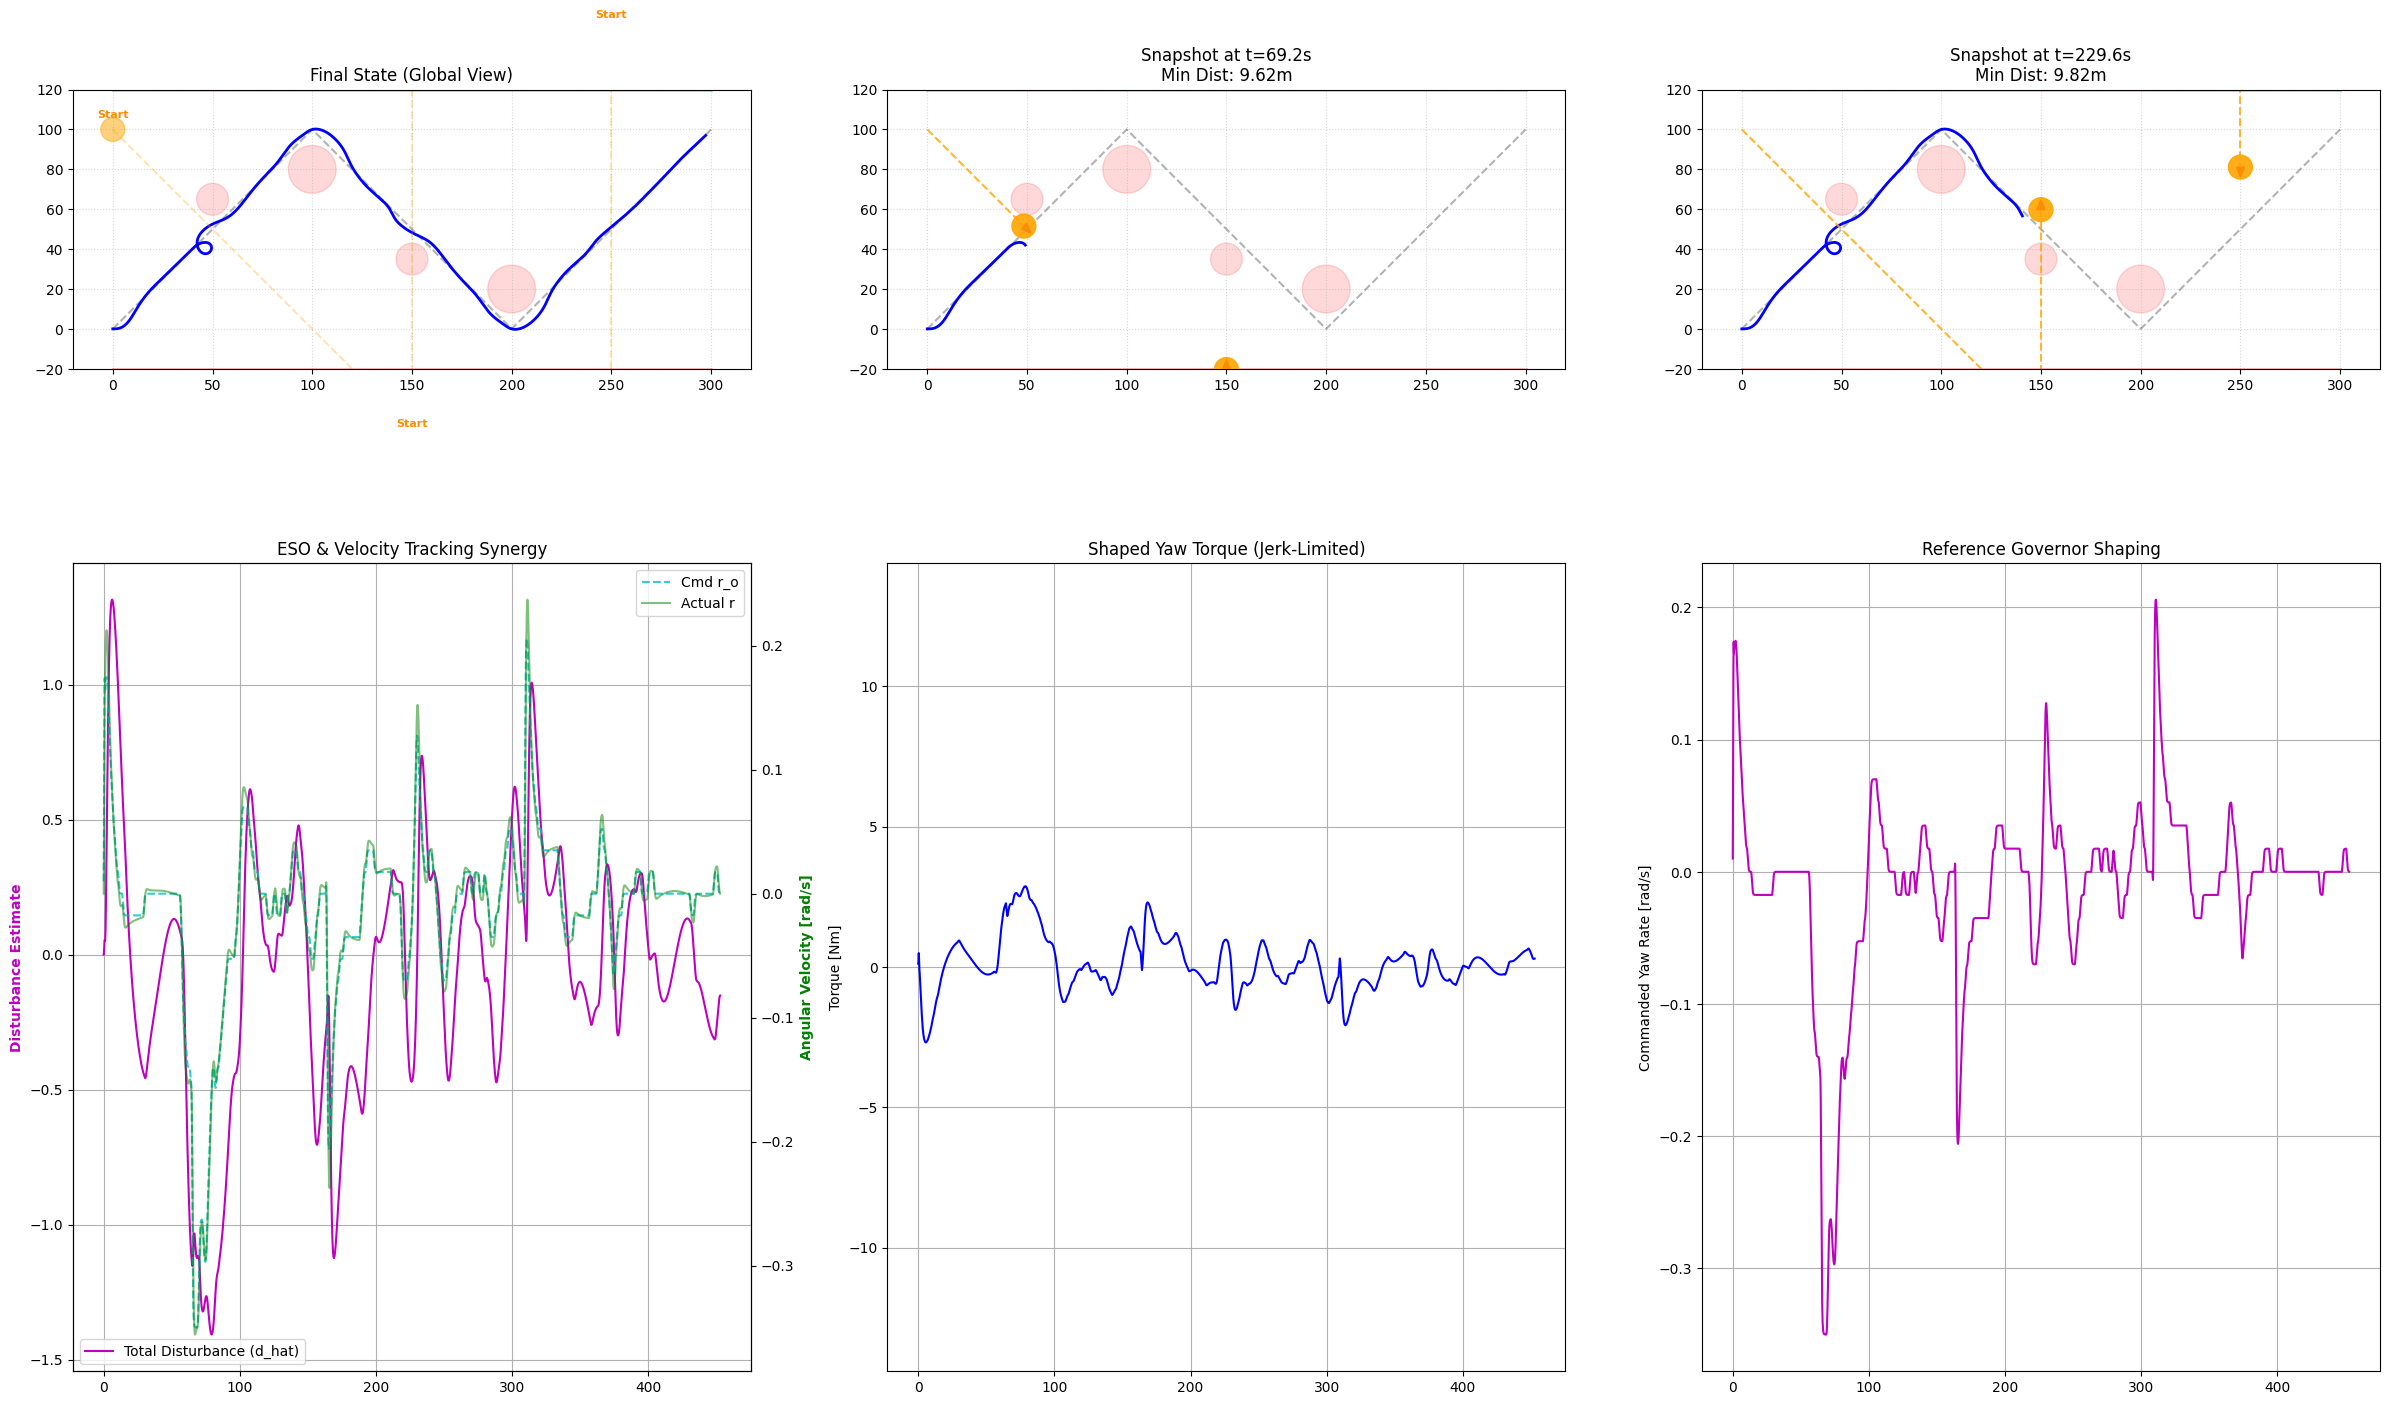

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import time
import json

# =====================================================================
# UNIFIED Environment CONFIGURATION
# =====================================================================
AUV_CONFIG = {
    'dt': 0.1,
    'sim_time': 600.0,
    'm_r': 10.0, 'd_r': 2.0,
    'delta': 5.0, 'kp_psi': 1.0, 'max_yaw_rate': 0.5, 'acceptance_radius': 4.0,

    # Kinetic Controller & Reference Governor
    'kp_r': 6.0, 'tau_max': 12.0, 'max_r_dot': 0.6,
    'max_r_ddot': 1.0,

    'filter_tau': 0.4,
    'omega_o': 2.0, 'alpha': 0.75, 'eso_delta': 0.05,
    'rhp_horizon_time': 8.0, 'rhp_max_yaw_rate': 0.35, 'rhp_num_samples': 41,

    # ================= COMPLEX MARINE ENVIRONMENT =================

    # ================= COMPLEX MARINE ENVIRONMENT (场景二：发卡截击) =================

    # 巨大的 W 型折返航线，要求极高的转向跟踪能力
    'waypoints': np.array([
        [0, 0], [100, 100], [200, 0], [300, 100]
    ]),

    # 阴险的静态雷，全部放置在切弯的最短路径上，逼迫 AUV 绕大圈
    'static_obs': [
        [50, 65, 8.0],
        [100, 80, 12.0],  # 第一个发卡弯内侧
        [150, 35, 8.0],
        [200, 20, 12.0]   # 第二个发卡弯内侧
    ],

    # 限制整体活动海域的外围墙壁
    'line_obs': [
        [0, 120, 300, 120, 4.0],
        [0, -20, 300, -20, 4.0]
    ],

    # 算好提前量的“截击鱼雷”
    'dynamic_obs': [
        # 1. 交叉斜切：与 AUV 第一段航线呈 X 型交叉，大约在 t=70s 命中 [50, 50]
        [0, 100, 0.7, -0.7, 6.0],

        # 2. 垂直切弯：在 AUV 下坡的关键时刻 (t=210s 左右) 垂直封锁 [150, 50]
        [150, -55, 0.0, 0.5, 6.0],

        # 3. 终点幽灵：在 AUV 即将到达终点前，以缓慢的速度在前方徘徊
        [250, 150, 0.0, -0.3, 6.0]
    ]
}
AUV_CONFIG['b0'] = 0.5
# ================= 配置结束 =================

# =====================================================================
# CORE ALGORITHMS (Filters, Observers, Governors)
# =====================================================================

class AUVDynamics:
    """
    Standard 3-DOF AUV dynamics including Added Mass, Coriolis, and Damping.
    """
    def __init__(self):
        self.m = 18.0
        self.I_z = 1.0
        self.X_udot, self.Y_vdot, self.N_rdot = -1.0, -10.0, -1.0
        self.X_u, self.Y_v, self.N_r = -2.0, -5.0, -2.0
        self.X_uu, self.Y_vv, self.N_rr = -1.5, -10.0, -5.0

        self.M = np.array([
            [self.m - self.X_udot, 0, 0],
            [0, self.m - self.Y_vdot, 0],
            [0, 0, self.I_z - self.N_rdot]
        ])
        self.M_inv = np.linalg.inv(self.M)

    def update_state(self, eta, nu, tau, dt, d_real):
        u, v, r = nu[0], nu[1], nu[2]
        C = np.array([
            [0, 0, -(self.m - self.Y_vdot) * v],
            [0, 0,  (self.m - self.X_udot) * u],
            [(self.m - self.Y_vdot) * v, -(self.m - self.X_udot) * u, 0]
        ])
        D = np.array([
            [-self.X_u - self.X_uu * abs(u), 0, 0],
            [0, -self.Y_v - self.Y_vv * abs(v), 0],
            [0, 0, -self.N_r - self.N_rr * abs(r)]
        ])

        # Dynamics: M*nu_dot + C*nu + D*nu = tau + disturbance
        # We assume disturbance is integrated into yaw for simplicity here
        dist_vec = np.array([0, 0, d_real * self.M[2,2]])
        nu_dot = self.M_inv.dot(tau - C.dot(nu) - D.dot(nu) + dist_vec)
        nu_next = nu + nu_dot * dt

        # Kinematics: eta_dot = R(psi)*nu
        psi = eta[2]
        R = np.array([
            [np.cos(psi), -np.sin(psi), 0],
            [np.sin(psi),  np.cos(psi), 0],
            [0, 0, 1]
        ])
        eta_next = eta + R.dot(nu) * dt
        eta_next[2] = (eta_next[2] + np.pi) % (2 * np.pi) - np.pi
        return eta_next, nu_next

class FirstOrderCommandFilter:
    def __init__(self, max_rate, max_accel, dt, tau):
        self.max_rate = max_rate
        self.max_accel = max_accel
        self.dt = dt
        self.tau = tau
        self.r_f = 0.0

    def update(self, r_cmd_raw):
        r_dot_desired = (r_cmd_raw - self.r_f) / self.tau
        r_dot_limited = np.clip(r_dot_desired, -self.max_accel, self.max_accel)
        self.r_f += r_dot_limited * self.dt
        self.r_f = np.clip(self.r_f, -self.max_rate, self.max_rate)
        return self.r_f

def fal(e, alpha, delta):
    if abs(e) <= delta:
        return e / (delta ** (1.0 - alpha))
    return (abs(e) ** alpha) * np.sign(e)

class NonlinearESO:
    def __init__(self, b0, omega_o, dt, alpha, delta):
        self.b0 = b0
        self.dt = dt
        self.beta1 = 2.0 * omega_o
        self.beta2 = omega_o ** 2
        self.alpha = alpha
        self.delta = delta
        self.z = np.zeros(2)

    def update(self, y, u):
        e = self.z[0] - y
        z1_dot = self.z[1] - self.beta1 * e + self.b0 * u
        z2_dot = -self.beta2 * fal(e, self.alpha, self.delta)
        self.z += np.array([z1_dot, z2_dot]) * self.dt
        return self.z[0], self.z[1]

# class SmoothReferenceGovernor:
#     def __init__(self, tau_max, max_r_dot, dt, safety_margin=0.9):
#         self.tau_max = tau_max
#         self.safe_tau_max = tau_max * safety_margin
#         self.max_r_dot = max_r_dot
#         self.dt = dt
#         self.r_o_prev = 0.0

#     def govern(self, r_cmd, r_measure, d_hat, b0, kp_r):
#         r_lower_tau = r_measure + (d_hat - self.safe_tau_max * b0) / kp_r
#         r_upper_tau = r_measure + (d_hat + self.safe_tau_max * b0) / kp_r
#         r_lower_rate = self.r_o_prev - self.max_r_dot * self.dt
#         r_upper_rate = self.r_o_prev + self.max_r_dot * self.dt

#         r_min = max(r_lower_tau, r_lower_rate)
#         r_max = min(r_upper_tau, r_upper_rate)
#         r_o = np.clip(r_cmd, r_min, r_max)
#         self.r_o_prev = r_o
#         return r_o

class JerkLimitedGovernor:
    """
    Advanced Governor limiting Torque (Value), Rate (Acceleration),
    and Jerk (Rate of change of acceleration).
    """
    def __init__(self, tau_max, max_r_dot, max_r_ddot, dt, safety_margin=0.9):
        self.tau_max = tau_max
        self.safe_tau_max = tau_max * safety_margin
        self.max_r_dot = max_r_dot
        self.max_r_ddot = max_r_ddot # Jerk Limit
        self.dt = dt
        self.r_o_prev = 0.0
        self.r_dot_prev = 0.0

    def govern(self, r_cmd, r_measure, d_hat, b0, kp_r):
        # 1. Calc current feasible acceleration range from ESO and Torque limits
        r_dot_min_tau = (d_hat - self.safe_tau_max * b0) / kp_r
        r_dot_max_tau = (d_hat + self.safe_tau_max * b0) / kp_r

        # 2. Apply Jerk limit to the acceleration
        r_dot_lower_jerk = self.r_dot_prev - self.max_r_ddot * self.dt
        r_dot_upper_jerk = self.r_dot_prev + self.max_r_ddot * self.dt

        # 3. Integrate to find feasible velocity range
        r_dot_min = max(r_dot_min_tau, r_dot_lower_jerk, -self.max_r_dot)
        r_dot_max = min(r_dot_max_tau, r_dot_upper_jerk, self.max_r_dot)

        # 4. Final Velocity Command Governing
        r_o = np.clip(r_cmd, self.r_o_prev + r_dot_min * self.dt, self.r_o_prev + r_dot_max * self.dt)

        self.r_dot_prev = (r_o - self.r_o_prev) / self.dt
        self.r_o_prev = r_o
        return r_o

# =====================================================================
# RECEDING HORIZON PLANNER （HETEROGENEOUS）
# =====================================================================
import numpy as np

def soft_switch(dist, threshold=15.0, width=5.0, val_safe=25.0, val_danger=5.0):
    """
    Adjust the lower limit of the penalty in the danger zone from 3.0 to 5.0
    to increase steering damping and suppress potential 'spikes' during avoidance.
    """
    z = (dist - threshold) / (width / 4)
    alpha = 1.0 / (1.0 + np.exp(-z))
    return val_danger + (val_safe - val_danger) * alpha

class AdvancedRHP:
    def __init__(self, horizon_time, dt, max_yaw_rate, num_samples):
        self.horizon_time = horizon_time
        self.dt = dt
        self.horizon_steps = int(horizon_time / dt)
        self.r_candidates = np.linspace(-max_yaw_rate, max_yaw_rate, num_samples)
        self.time_array = np.arange(self.horizon_steps) * self.dt
        self.prev_optimal_r = 0.0

    def predict_trajectory(self, eta_init, nu_surge, r_cmd):
        eta_pred = np.zeros((self.horizon_steps, 3))
        eta_curr = np.copy(eta_init)
        for i in range(self.horizon_steps):
            psi = eta_curr[2]
            eta_curr[0] += nu_surge * np.cos(psi) * self.dt
            eta_curr[1] += nu_surge * np.sin(psi) * self.dt
            eta_curr[2] += r_cmd * self.dt
            eta_curr[2] = (eta_curr[2] + np.pi) % (2 * np.pi) - np.pi
            eta_pred[i] = eta_curr
        return eta_pred

    def calculate_barrier_penalty(self, min_dist, obs_radius, AUV_RADIUS=2.0):
        """
        Mathematical barrier: Retains gradients using polynomial functions instead of 'inf'.
        """
        if min_dist <= obs_radius + AUV_RADIUS:
            # Depth of penetration
            penetration = (obs_radius + AUV_RADIUS) - min_dist
            # Quadratic resistance + Cubic repulsion:
            # The cubic term ensures the penalty grows drastically, providing a clear gradient for the optimizer.
            return 500.0 + 3000.0 * (penetration ** 2) + 10000.0 * (penetration ** 3)
        else:
            # Tighten the field (decay from -1.0 to -2.0) to eliminate S-turns caused by long-range influence.
            return 500.0 * np.exp(-2.0 * (min_dist - (obs_radius + AUV_RADIUS)))

    def evaluate_cost(self, traj, wp_prev, wp_next, static_obs, line_obs, dynamic_obs, r_cmd, current_time, s_max):
        final_pos = traj[-1, 0:2]
        traj_pos = traj[:, 0:2]

        min_dist_all = 100.0
        for obs in static_obs:
            min_dist_all = min(min_dist_all, np.min(np.linalg.norm(traj_pos - np.array([obs[0], obs[1]]), axis=1)) - obs[2])
        for dobs in dynamic_obs:
            d = np.linalg.norm(traj_pos[0] - np.array([dobs[0]+dobs[2]*current_time, dobs[1]+dobs[3]*current_time])) - dobs[4]
            min_dist_all = min(min_dist_all, d)

        penalty_factor = soft_switch(min_dist_all, threshold=15.0, width=5.0)
        chatter_penalty = penalty_factor * abs(r_cmd - self.prev_optimal_r)

        # --- 1. 目标进度 (Distance) ---
        dist_cost = 2.0 * np.linalg.norm(wp_next - final_pos)

        # --- 2. 【全新加入】航线死咬逻辑 (CTE & Heading) ---
        seg_vec = wp_next - wp_prev
        seg_len = np.linalg.norm(seg_vec)
        if seg_len > 0:
            seg_dir = seg_vec / seg_len
            path_yaw = np.arctan2(seg_dir[1], seg_dir[0])

            # 计算终端横向误差 (Cross-Track Error)
            AP = final_pos - wp_prev
            proj = np.dot(AP, seg_dir)
            perp_vec = AP - proj * seg_dir
            cte = np.linalg.norm(perp_vec)
            cte_cost = 1.5 * cte      # 从钢铁轨道变成柔韧皮筋


            # 计算终端航向误差 (Heading Error)
            final_yaw = traj[-1, 2]
            yaw_err = abs((final_yaw - path_yaw + np.pi) % (2 * np.pi) - np.pi)
            yaw_cost = 1.0 * yaw_err  # 允许车头在避障时有更灵活的偏航
        else:
            cte_cost = 0.0
            yaw_cost = 0.0

        obs_penalty = 0.0

        # Static Circular Obstacles
        for obs in static_obs:
            dists = np.linalg.norm(traj_pos - np.array([obs[0], obs[1]]), axis=1)
            penalty = self.calculate_barrier_penalty(np.min(dists), obs[2])
            if penalty == float('inf'): return float('inf')
            obs_penalty += penalty

        # Dynamic Moving Obstacles
        for dobs in dynamic_obs:
            obs_x = dobs[0] + dobs[2] * (current_time + self.time_array)
            obs_y = dobs[1] + dobs[3] * (current_time + self.time_array)
            dists = np.linalg.norm(traj_pos - np.column_stack((obs_x, obs_y)), axis=1)
            penalty = self.calculate_barrier_penalty(np.min(dists), dobs[4])
            if penalty == float('inf'): return float('inf')
            obs_penalty += penalty * 1.5

        # Line Segment Obstacles
        for l_obs in line_obs:
            A, B = np.array([l_obs[0], l_obs[1]]), np.array([l_obs[2], l_obs[3]])
            AB = B - A
            len_sq = np.dot(AB, AB)
            if len_sq == 0:
                dists = np.linalg.norm(traj_pos - A, axis=1)
            else:
                t = np.clip(np.dot(traj_pos - A, AB) / len_sq, 0.0, 1.0)
                proj = A + np.outer(t, AB)
                dists = np.linalg.norm(traj_pos - proj, axis=1)
            penalty = self.calculate_barrier_penalty(np.min(dists), l_obs[4])
            if penalty == float('inf'): return float('inf')
            obs_penalty += penalty

        effort_penalty = 1.0 * abs(r_cmd)

        return dist_cost + cte_cost + yaw_cost + obs_penalty + chatter_penalty + effort_penalty

    def get_optimal_command(self, eta, nu_surge, wp_prev, wp_next, static_obs, line_obs, dynamic_obs, current_time, s_max):
        best_cost = float('inf')
        optimal_r = 0.0
        for r_cmd in self.r_candidates:
            traj = self.predict_trajectory(eta, nu_surge, r_cmd)
            cost = self.evaluate_cost(traj, wp_prev, wp_next, static_obs, line_obs, dynamic_obs, r_cmd, current_time, s_max)
            if cost < best_cost:
                best_cost = cost
                optimal_r = r_cmd

        # Absolute fail-safe since evaluate_cost should no longer return inf
        if best_cost >= 1e9:
            optimal_r = -self.r_candidates[-1]
        else:
            self.prev_optimal_r = optimal_r

        return optimal_r

# =====================================================================
# UNIFIED SIMULATION ENGINE
# =====================================================================

def run_comprehensive_simulation(config=AUV_CONFIG):
    dt = config['dt']
    steps = int(config['sim_time'] / dt)

    # State initialization
    eta = np.array([config['waypoints'][0][0], config['waypoints'][0][1], 0.0])
    nu = np.array([1.0, 0.0, 0.0]) # Surge, Sway, Yaw rate

    wps = config['waypoints']
    current_wp_idx = 1
    b0, kp_r = config['b0'], config['kp_r']

    # Sub-module initialization
    planner = AdvancedRHP(config['rhp_horizon_time'], dt, config['rhp_max_yaw_rate'], config['rhp_num_samples'])
    eso = NonlinearESO(b0, config['omega_o'], dt, config['alpha'], config['eso_delta'])

    rg = JerkLimitedGovernor(config['tau_max'], config['max_r_dot'], config.get('max_r_ddot', 1.0), dt)
    cmd_filter = FirstOrderCommandFilter(config['max_yaw_rate'], config['max_r_dot'], dt, tau=config['filter_tau'])
    dynamics = AUVDynamics()

    # Logging setup
    log = {
        'eta': np.zeros((steps, 3)), 'tau': np.zeros(steps),
        'd_real': np.zeros(steps), 'd_hat': np.zeros(steps),
        'r_cmd_raw': np.zeros(steps), 'r_o': np.zeros(steps),
        'r_actual': np.zeros(steps),
        'dist_to_obs': []
    }

    # Critical Event Tracking
    critical_events = {idx: (float('inf'), 0, None, None) for idx in range(len(config['dynamic_obs']))}
    s_max = 0.0
    r_raw_history = [] # B-Spline

    for i in range(steps):
        time_sec = i * dt
        log['eta'][i] = eta
        wp_k, wp_k_prev = wps[current_wp_idx], wps[current_wp_idx - 1]

        # --- 1. Arrival Detection & Early Stop ---
        if current_wp_idx == len(wps) - 1:
            dist_to_final = np.linalg.norm(eta[0:2] - wp_k[0:2])
            if dist_to_final <= config['acceptance_radius']:
                print(f"Goal reached at {time_sec:.2f}s. Ending simulation.")
                for key in log:
                    if isinstance(log[key], np.ndarray): log[key] = log[key][:i]
                break

        # --- 2. Near-Miss Tracking ---
        for idx, dobs in enumerate(config['dynamic_obs']):
            obs_pos = np.array([dobs[0] + dobs[2]*time_sec, dobs[1] + dobs[3]*time_sec])
            d = np.linalg.norm(eta[0:2] - obs_pos)
            if d < critical_events[idx][0]:
                critical_events[idx] = (d, i, np.copy(eta), obs_pos)

        # Waypoint Switching Logic
        seg_vec = wp_k - wp_k_prev
        pi_p = np.arctan2(seg_vec[1], seg_vec[0])
        s = (eta[0]-wp_k_prev[0])*np.cos(pi_p) + (eta[1]-wp_k_prev[1])*np.sin(pi_p)
        dist_to_wp = np.linalg.norm(eta[0:2] - wp_k[0:2])
        if (s >= np.linalg.norm(seg_vec) or dist_to_wp < config['acceptance_radius']) and current_wp_idx < len(wps) - 1:
            current_wp_idx += 1
            wp_k, wp_k_prev = wps[current_wp_idx], wps[current_wp_idx-1]
            s_max = 0.0
        else:
            s_max = max(s_max, s)

        # --- 3. Guidance & Planning ---
        r_cmd_raw = planner.get_optimal_command(eta, nu[0], wp_k_prev, wp_k,
                                               config['static_obs'], config['line_obs'], config['dynamic_obs'],
                                               time_sec, s_max)

        r_raw_history.append(r_cmd_raw)
        if len(r_raw_history) > 10: r_raw_history.pop(0)

        r_cmd_smoothed = np.mean(r_raw_history)

        r_cmd_f = cmd_filter.update(r_cmd_smoothed)
        log['r_cmd_raw'][i] = r_cmd_raw

        # --- 4. Control Layer (ESO + RG) ---
        d_hat = eso.z[1]
        r_o = rg.govern(r_cmd_f, nu[2], d_hat, b0, kp_r)
        log['r_o'][i] = r_o

        # Torque calculation (Yaw)
        tau_yaw_req = kp_r * (r_o - nu[2])
        tau_yaw = (tau_yaw_req - d_hat) / b0
        tau_yaw = np.clip(tau_yaw, -config['tau_max'], config['tau_max'])

        # Simple Surge Control (Maintain constant speed)
        tau_surge = 10.0 * (1.0 - nu[0]) + 3.5
        tau_vec = np.array([tau_surge, 0.0, tau_yaw])

        log['tau'][i] = tau_yaw
        log['r_actual'][i] = nu[2]

        # --- 5. Environment & Dynamics ---
        d_real = 0.2 * np.sin(0.15 * time_sec) + 0.1 * np.cos(0.05 * time_sec)
        log['d_real'][i] = d_real
        log['d_hat'][i] = d_hat

        eso.update(y=nu[2], u=tau_yaw)
        eta, nu = dynamics.update_state(eta, nu, tau_vec, dt, d_real)

    return log, config, critical_events

# =====================================================================
# UNIFIED MULTI-PANEL VISUALIZATION (Fixed Trajectories & Arrows)
# =====================================================================
def draw_global_map(ax, trajectory, config, current_time=None):
    """Unified helper for global maps. Now supports truncated paths and directional arrows."""
    wps = config['waypoints']
    ax.plot(wps[:, 0], wps[:, 1], 'k--', alpha=0.3, label='Global Route')
    ax.plot(trajectory[:, 0], trajectory[:, 1], 'b-', linewidth=2, label='AUV Path')

    for obs in config['static_obs']:
        ax.add_patch(plt.Circle((obs[0], obs[1]), obs[2], color='red', alpha=0.15))
    for l_obs in config['line_obs']:
        ax.plot([l_obs[0], l_obs[2]], [l_obs[1], l_obs[3]], 'r-', linewidth=2, alpha=0.3)

    for dobs in config['dynamic_obs']:
        if current_time is None:
            # [Global Final Diagram]: Mark the starting point and display the complete expected trajectory
            t_max = config['sim_time']
            alpha_line = 0.3
            ax.add_patch(plt.Circle((dobs[0], dobs[1]), dobs[4], color='orange', alpha=0.5, zorder=3))
            ax.text(dobs[0], dobs[1]+6, 'Start', color='darkorange', fontsize=8, ha='center', fontweight='bold')
        else:
            # 【Freeze Snapshot】: Only draw the trajectory up to current_time, and render the entity at its current position
            t_max = current_time
            alpha_line = 0.8
            cx, cy = dobs[0] + dobs[2]*current_time, dobs[1] + dobs[3]*current_time
            ax.add_patch(plt.Circle((cx, cy), dobs[4], color='orange', alpha=0.9, zorder=3))

        t_arr = np.linspace(0, t_max, max(10, int(t_max)))
        traj_x = dobs[0] + dobs[2]*t_arr
        traj_y = dobs[1] + dobs[3]*t_arr
        ax.plot(traj_x, traj_y, color='orange', linestyle='--', alpha=alpha_line, linewidth=1.5)

        if len(traj_x) > 1 and t_max > 0:
            dx = traj_x[-1] - traj_x[-2]
            dy = traj_y[-1] - traj_y[-2]
            norm = np.hypot(dx, dy)
            if norm > 0:
                ax.arrow(traj_x[-1], traj_y[-1], (dx/norm)*0.01, (dy/norm)*0.01,
                         head_width=4.0, head_length=5.0, fc='darkorange', ec='darkorange', zorder=4)

    ax.set_aspect('equal')
    ax.set_xlim([-20, 320]); ax.set_ylim([-20, 120])
    ax.grid(True, linestyle=':', alpha=0.5)

def plot_comprehensive_analysis(log, config, critical_events):
    dt = config['dt']
    steps = len(log['eta'])
    time_vector = np.linspace(0, steps * dt, steps)

    fig = plt.figure(figsize=(24, 16))
    gs = GridSpec(2, 6, figure=fig)

    # 1. Final Trajectory
    ax1 = fig.add_subplot(gs[0, 0:2])
    draw_global_map(ax1, log['eta'], config)
    ax1.set_title('Final State (Global View)')

    # 2. Critical Snapshots
    events = [e for e in critical_events.values() if e[2] is not None]
    sorted_ev = sorted(events, key=lambda x: x[0])[:2]
    for i, ev in enumerate(sorted_ev):
        ax_snap = fig.add_subplot(gs[0, 2+i*2 : 4+i*2])
        dist, idx, _, _ = ev
        draw_global_map(ax_snap, log['eta'][:idx], config, current_time=idx*dt)
        ax_snap.set_title(f'Snapshot at t={idx*dt:.1f}s\nMin Dist: {dist:.2f}m')

    # 3. ESO & Tracking Synergy (Dual Axis)
    ax2 = fig.add_subplot(gs[1, 0:2])
    ax2.plot(time_vector, log['d_hat'], 'm', label='Total Disturbance (d_hat)', linewidth=1.5)
    ax2.set_ylabel('Disturbance Estimate', color='m', fontweight='bold')

    ax2_v = ax2.twinx()
    ax2_v.plot(time_vector, log['r_o'], 'c--', label='Cmd r_o', alpha=0.8)
    ax2_v.plot(time_vector, log['r_actual'], 'g-', label='Actual r', alpha=0.5)
    ax2_v.set_ylabel('Angular Velocity [rad/s]', color='g', fontweight='bold')
    ax2.set_title('ESO & Velocity Tracking Synergy'); ax2.grid(True)

    ax2.legend(loc='lower left')
    ax2_v.legend(loc='upper right')

    # 4. Smooth Torque
    ax3 = fig.add_subplot(gs[1, 2:4])
    ax3.plot(time_vector, log['tau'], 'b', linewidth=1.5)
    ax3.set_ylim([-config['tau_max']*1.2, config['tau_max']*1.2])
    ax3.set_ylabel('Torque [Nm]')
    ax3.set_title('Shaped Yaw Torque (Jerk-Limited)'); ax3.grid(True)

    # 5. Reference Governor Output
    ax4 = fig.add_subplot(gs[1, 4:6])
    ax4.plot(time_vector, log['r_o'], 'm', label='RG Output')
    ax4.set_ylabel('Commanded Yaw Rate [rad/s]')
    ax4.set_title('Reference Governor Shaping'); ax4.grid(True)

    plt.tight_layout(); plt.show()

if __name__ == "__main__":
    simulation_log, sim_config, critical_events = run_comprehensive_simulation()
    plot_comprehensive_analysis(simulation_log, sim_config, critical_events)